# HW1 — Stochastic Bandits

**Course:** ID6002W Online and Reinforcement Learning (IIT Madras WSAI web-enabled M.Tech)

**Deadline:** Wednesday, 27 May 2026, 11:59 PM.

**Marks:** 10 total — Task 1 (3) + Task 2 (3) + Task 3 (4).

## About this homework

Three tasks, exploring three classical stochastic-bandit algorithms: ε-greedy, Explore-Then-Commit (ETC), and Successive Elimination (SE). Each task has the same structure:

1. **Implement** the algorithm's core logic in a `# TODO` cell.
2. **Run** pre-filled experiment and plotting cells.
3. **Comment** on what you see in a short write-up cell.

Both your code and your written observations carry marks. The plotting and experiment scaffolding is provided — your focus is on getting the algorithms right and interpreting the results.

**Prerequisite:** work through `HW1_warmup.ipynb` first. It introduces the environment, plotting helpers, and the `run_experiment` harness used here. The code below is duplicated from warmup so this notebook is self-contained.

**Reproducibility:** all randomness is seeded from `BASE_SEED`. Do not call `np.random.seed(...)` or `np.random.rand(...)` directly — use the per-run RNG `env.rng` that the harness provides.

## Provided codebase (from warmup)

The next four cells provide imports, `BernoulliBandit`, plotting helpers, and `run_experiment`. These are identical to the warmup notebook — included here so this homework is self-contained. Run them once, then move on to Task 1.

In [32]:
# === Setup: imports and plotting style ===

from tqdm.notebook import tqdm, trange       # progress bars
import numpy as np  # numerical arrays + random number generators
import matplotlib.pyplot as plt  # plotting
from functools import (
    partial,
)  # used later to "bind" hyperparameters (e.g. ε) into algorithms

%matplotlib inline

# A few plot defaults so figures look consistent across the notebook.
plt.rcParams["figure.dpi"] = 100  # higher dpi = sharper figures
plt.rcParams["axes.grid"] = True  # show grid by default
plt.rcParams["grid.alpha"] = 0.3  # faded grid lines so they don't dominate

# Fixed starting seed for reproducibility (see warmup for explanation).
BASE_SEED = 20260516

In [2]:
# === Provided: BernoulliBandit environment ===


class BernoulliBandit:
    """
    K-arm Bernoulli bandit.

    Parameters
    ----------
    means : sequence of floats in [0, 1]
        True mean reward of each arm.
    rng : np.random.Generator
        Source of randomness owned by this environment instance.

    Attributes
    ----------
    K : int                       Number of arms.
    means : np.ndarray (K,)       True means.
    best_mean : float             max of `means` (used for regret).
    best_arm : int                argmax of `means`.
    pull_counts : np.ndarray (K,) Number of times each arm has been pulled.
    """

    def __init__(self, means, rng):
        # Store true means as a numpy array of floats.
        self.means = np.asarray(means, dtype=float)

        # Sanity check: Bernoulli means must be valid probabilities.
        if np.any((self.means < 0) | (self.means > 1)):
            raise ValueError("Bernoulli means must lie in [0, 1].")

        self.K = len(self.means)  # number of arms
        self.rng = rng  # this env's own random generator

        # Pre-compute best arm and its mean — used to compute regret.
        self.best_mean = float(self.means.max())
        self.best_arm = int(np.argmax(self.means))

        # Bookkeeping: how often each arm has been pulled so far.
        # (Algorithms may also track this internally; this is for sanity-checking.)
        self.pull_counts = np.zeros(self.K, dtype=int)

    def pull(self, arm):
        """Pull arm `arm`. Returns a 0/1 reward sampled Bernoulli(means[arm])."""
        self.pull_counts[arm] += 1
        # rng.random() draws uniform in [0, 1); reward = 1 with probability means[arm].
        return int(self.rng.random() < self.means[arm])

    def instantaneous_regret(self, arm):
        """Expected regret incurred by pulling arm `arm`: best_mean − means[arm].

        Note this is the *expected* regret, not the realised one. We use expected
        regret throughout because it's smoother and the standard quantity to plot.
        """
        return self.best_mean - self.means[arm]

In [3]:
# === Provided: plotting helpers ===


def plot_cumulative_regret(regrets, label, ax):
    """Plot cumulative regret for a single run.

    Parameters
    ----------
    regrets : (T,) instantaneous regret per round (not cumulative — we sum here).
    """
    ax.plot(
        np.cumsum(regrets), label=label
    )  # cumsum turns per-round regret into cumulative
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret")
    ax.legend()


def plot_averaged_regret(regret_matrix, label, ax, with_band=True):
    """Plot mean cumulative regret across seeds, with optional ±1 std band.

    Parameters
    ----------
    regret_matrix : (n_seeds, T) instantaneous regret per round per seed.
    """
    # Each row is one run; cumsum along time gives (n_seeds, T) cumulative regrets.
    cum = np.cumsum(regret_matrix, axis=1)

    # Aggregate across seeds: mean curve plus standard-deviation band.
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)

    t = np.arange(1, cum.shape[1] + 1)
    (line,) = ax.plot(t, mean, label=label)
    if with_band:
        # Shaded band shows variability across seeds — wider band = noisier algorithm.
        ax.fill_between(t, mean - std, mean + std, alpha=0.2, color=line.get_color())
    ax.set_xlabel("Round t")
    ax.set_ylabel("Cumulative regret  (mean ± 1 std)")
    ax.legend()


def plot_arm_pulls(arm_sequence, ax, K=None):
    """Strip plot: which arm was pulled at which round.

    Useful for visualising the exploration pattern of an algorithm.

    Parameters
    ----------
    arm_sequence : (T,) integer arm indices.
    """
    arm_sequence = np.asarray(arm_sequence)
    t = np.arange(len(arm_sequence))
    ax.scatter(t, arm_sequence, s=6, alpha=0.5)  # small, semi-transparent dots
    ax.set_xlabel("Round t")
    ax.set_ylabel("Arm pulled")
    if K is None:
        K = int(arm_sequence.max()) + 1
    ax.set_yticks(np.arange(K))  # one tick per arm

In [58]:
# === Provided: run_experiment helper ===


def run_experiment(algo_fn, env_factory, T, n_seeds, base_seed=BASE_SEED, progress_bar=True):
    """Run `algo_fn` for `n_seeds` independent seeds.

    Parameters
    ----------
    algo_fn : callable
        Signature `algo_fn(env, T) -> (arm_sequence, regret_sequence)`.
        Bind any extra params (e.g. ε for ε-greedy) with `functools.partial`
        before passing.
    env_factory : callable
        Signature `env_factory(rng) -> BernoulliBandit`. Builds a fresh env per
        seed — so each seed sees an independent stream of rewards.
    T : int                Horizon.
    n_seeds : int          Number of independent runs to average over.
    base_seed : int        Seeds used are base_seed + 0, base_seed + 1, ...
    progress_bar : bool     Whether to show a progress bar (useful for long experiments).

    Returns
    -------
    regret_matrix : (n_seeds, T) float array of instantaneous regrets.
    arm_matrix    : (n_seeds, T) int   array of arms pulled.
    """
    # Pre-allocate output matrices: one row per seed, one column per round.
    regret_matrix = np.zeros((n_seeds, T))
    arm_matrix = np.zeros((n_seeds, T), dtype=int)

    for s in trange(n_seeds, disable=not progress_bar, desc="Seeds"):
        # Each run gets its own RNG, derived from base_seed + s.
        # This makes the whole experiment reproducible while keeping runs independent.
        rng = np.random.default_rng(base_seed + s)
        env = env_factory(rng)

        # Run the algorithm. It returns the arms it pulled and the per-round regret.
        arms, regrets = algo_fn(env, T)

        regret_matrix[s] = regrets
        arm_matrix[s] = arms

    return regret_matrix, arm_matrix

---

## Task 1 — ε-greedy (3 marks)

ε-greedy is the simplest non-trivial bandit algorithm. At each round, with probability ε **explore** (pull a uniformly random arm) and with probability 1−ε **exploit** (pull the arm with the highest empirical mean so far).

In this task you'll implement ε-greedy and study it from three angles.

**Part A (1 mark): A few fixed values of ε, one horizon.** Fix the horizon $T$ and run ε-greedy for several values of ε. Look at cumulative regret over time. Write up what you see about the *shape* of these curves and how variability across seeds depends on ε.

**Part B (1 mark): Sweep ε across several horizons.** Plot final cumulative regret as a function of ε, with one curve per horizon $T$. Comment on the shape of each curve and how it shifts as $T$ grows.

**Part C (1 mark): A decaying schedule.** Use $\varepsilon_t = \min(1, c/t)$ instead of a fixed ε. Compare it to the best fixed ε from Part B at the same horizon. Comment on which one wins, and over what time scale.

**How this task works.** You implement the ε-greedy algorithm once, in a code cell marked `# TODO`. Everything else — experiment setup, plotting, decay schedule — is provided. Your job is to (1) get the algorithm right, and (2) write thoughtful observations in the write-up cells (also marked `# TODO` or `**TODO**`).

In [36]:
# === Task 1: ε-greedy implementation ===


def epsilon_greedy(env, T, epsilon):
    """ε-greedy on a Bernoulli bandit.

    At each round t = 0, 1, ..., T-1:
      - with probability epsilon, pull a uniformly random arm (explore)
      - otherwise, pull the arm with the highest empirical mean so far (exploit)

    Ties in empirical means should be broken uniformly at random
    (use env.rng for all randomness, see warmup notebook).

    Parameters
    ----------
    env : BernoulliBandit
    T : int                    horizon
    epsilon : float in [0, 1]  exploration probability

    Returns
    -------
    arm_sequence    : (T,) int     arm pulled at each round
    regret_sequence : (T,) float   instantaneous (expected) regret per round
    """
    K = env.K       # number of arms
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    # Per-arm bookkeeping for empirical means.
    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)

    for t in range(T):
        if env.rng.random() < epsilon:
            a = env.rng.integers(K)
        else:
            # Handle zero counts by treating them as +∞ empirical mean, so that any unpulled arm gets pulled before any pulled arm.
            emperical_means = np.array([sum_rewards[i] / counts[i] if counts[i] > 0 else np.inf for i in range(K)])
            max_mean = np.max(emperical_means)
            best_arms = np.flatnonzero(emperical_means == max_mean)  # tie-breaking (flatnonzero so that in next step we get only single arm in a, not multiple)
            a = env.rng.choice(best_arms)
        
        # Pull, observe reward, update bookkeeping. (Provided.)
        r = env.pull(a)
        sum_rewards[a] += r
        counts[a] += 1

        arm_sequence[t] = a
        regret_sequence[t] = env.instantaneous_regret(a)

    return arm_sequence, regret_sequence

### Part A: a few fixed values of ε, one horizon

Fix the horizon $T$ and run ε-greedy for several values of ε. The cell below produces a single plot: cumulative regret over time, mean ± 1 std across seeds, one curve per ε.

Running ε-greedy with ε = 0.01...


  0%|          | 0/50 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.05...


  0%|          | 0/50 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.1...


  0%|          | 0/50 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.3...


  0%|          | 0/50 [00:00<?, ?it/s]

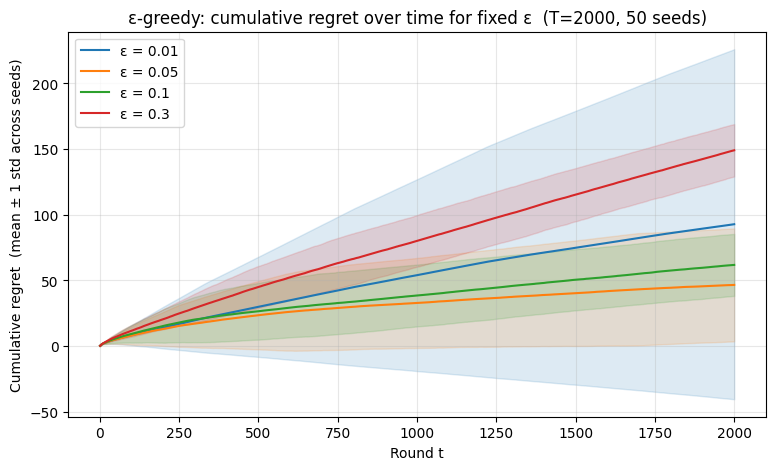

In [37]:
# === Task 1, Part A: ε-greedy trajectories at a few fixed ε ===

T = 2000
n_seeds = 50
epsilons_A = [0.01, 0.05, 0.1, 0.3]


def env_factory_5arm(rng):
    """5-arm Bernoulli env used throughout Task 1."""
    return BernoulliBandit([0.2, 0.4, 0.5, 0.55, 0.7], rng)


# Run ε-greedy for each ε, collect cumulative regret matrices.
results_A = {}  # ε -> (n_seeds, T) cumulative regret matrix
for eps in epsilons_A:
    print(f"Running ε-greedy with ε = {eps}...")
    algo = partial(epsilon_greedy, epsilon=eps)
    regret_matrix, _ = run_experiment(algo, env_factory_5arm, T, n_seeds)
    results_A[eps] = np.cumsum(regret_matrix, axis=1)

# Plot: averaged cumulative regret with ±1 std band, one curve per ε.
fig, ax = plt.subplots(figsize=(9, 5))
t = np.arange(1, T + 1)
for eps in epsilons_A:
    cum = results_A[eps]
    mean = cum.mean(axis=0)
    std = cum.std(axis=0)
    (line,) = ax.plot(t, mean, label=f"ε = {eps}")
    ax.fill_between(t, mean - std, mean + std, alpha=0.15, color=line.get_color())
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret  (mean ± 1 std across seeds)")
ax.set_title(
    f"ε-greedy: cumulative regret over time for fixed ε  (T={T}, {n_seeds} seeds)"
)
ax.legend()
plt.show()

**Observe and write up (TODO).** Looking at the plot above, address the following in a few sentences each:

1. Describe the **shape** of the cumulative regret curve for each ε. Are they linear? Sub-linear? Mixed? Pick at least two ε values and contrast them.

2. How does the **width of the ±1 std band** depend on ε? Why?

3. At T = 2000, which ε achieves the lowest mean cumulative regret? Is the ranking what you expected?

**Observations**:

1. Cumulative regrets for all $\epsilon$ are sub-linear (i.e. cumulative regret grows slower than number of rounds). Slowest cumulative regret growth is in smallest $\epsilon = 0.05$ (i.e. least exploration, maximum exploitation) and largest regret is in $\epsilon = 0.3$ (most exploration).
2. Widths of $\pm 1$ std band in descending order are (epsilons) [0.01, 0.05, 0.1, 0.3]. This is because when $\epsilon = 0.01$ (very low exploration probability), there's a high chance of some seeds getting unlucky initially and getting locked into bad arm means (taking a long time to correct the error). That's why it has very high variance. On the other hand, when $\epsilon = 0.3$ (30%), all the arms have sufficient time to explore and so there's very little chance of getting locked onto a bad arm - so its variance is low.
3. Lowest mean cumulative regret is in $\epsilon = 0.05$, which is expected as it does least exploration, maximum exploitation.

### Part B: ε sweep across several horizons

Now sweep ε across a grid and plot final cumulative regret as a function of ε, with one curve per horizon $T$. The minimum of each curve is marked with an empty circle.

Running ε-greedy with ε = 0.01...


  0%|          | 0/100 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.05...


  0%|          | 0/100 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.1...


  0%|          | 0/100 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.2...


  0%|          | 0/100 [00:00<?, ?it/s]

Running ε-greedy with ε = 0.5...


  0%|          | 0/100 [00:00<?, ?it/s]

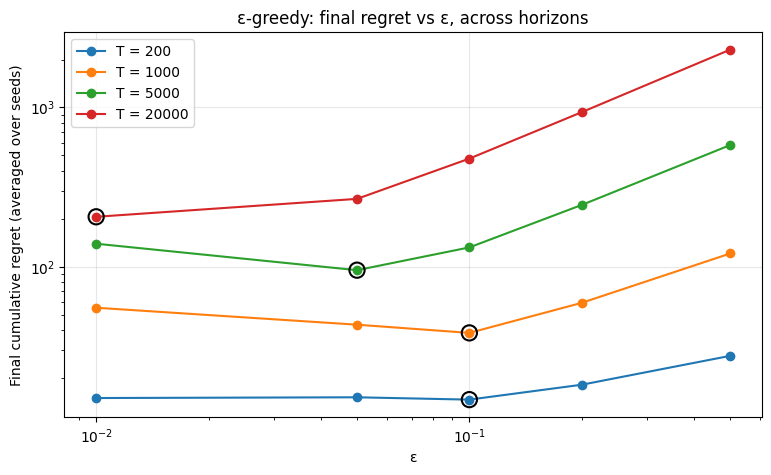

In [39]:
# === Task 1, Part B: ε sweep across several horizons ===

horizons_B = [200, 1000, 5000, 20000]
epsilons_B = [0.01, 0.05, 0.1, 0.2, 0.5]
n_seeds = 100

T_max = max(horizons_B)

# Run ε-greedy at the longest horizon for each ε; slice at each T.
# (Trick: at each ε, one run to T_max gives us cumulative regret at every T ≤ T_max for free.)
cum_by_eps = {}  # ε -> (n_seeds, T_max) cumulative regret matrix
for eps in epsilons_B:
    print(f'Running ε-greedy with ε = {eps}...')
    algo = partial(epsilon_greedy, epsilon=eps)
    regret_matrix, _ = run_experiment(algo, env_factory_5arm, T_max, n_seeds)
    cum_by_eps[eps] = np.cumsum(regret_matrix, axis=1)

# Plot: final cumulative regret vs ε, one curve per horizon.
fig, ax = plt.subplots(figsize=(9, 5))
for T in horizons_B:
    final_regrets = np.array([cum_by_eps[eps][:, T - 1].mean() for eps in epsilons_B])
    ax.plot(epsilons_B, final_regrets, marker="o", label=f"T = {T}")
    # Mark the minimum on each curve.
    i_star = int(np.argmin(final_regrets))
    ax.scatter(
        [epsilons_B[i_star]],
        [final_regrets[i_star]],
        s=120,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        zorder=5,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ε")
ax.set_ylabel("Final cumulative regret (averaged over seeds)")
ax.set_title("ε-greedy: final regret vs ε, across horizons")
ax.legend()
plt.show()

**Observe and write up (TODO).** Looking at the plot above:

1. Describe the **shape** of each curve. What's happening on the left side (small ε) vs the right side (large ε)?

2. Compare the curves across horizons. Which side of the curve (small ε or large ε) is more sensitive to T, and why?

3. Where does the minimum of each curve sit? Comment on how (or whether) the best ε shifts as T grows. Does your finding match what you'd predict from theory?

**Observations:**

1. Each curve is *piece-wise linear* - slope of the line is constant till one point, and then it increases. Overall, cumulative regret increases in each curve from left (small $\epsilon$) to right (large $\epsilon$).
2. From left (small $\epsilon$) to right (large $\epsilon$), curves become more sensitive to change in $T$ and diverge more (i.e. widening gap between curves of increasing $T$). **Reason**: The probability of making an error in Explore Then Commit (ETC) is bounded exponentially by $\exp{-m \Delta^2}$. As we choose a larger $m$ (more exploration samples), it takes a much smaller $\Delta$ to fool the system. Thus, the risk zone where we commit to a bad arm shifts leftward to tiny sub-gaps.
3. Minimums of each curve are at epsilons: T=200 => 0.1, T=1000 => 0.1, T=5000 => 0.05, T=20000 => 0.01. As $T$ grows, best $\epsilon$ reduces. This tells us that a fixed commitment timeline $m$ cannot simultaneously optimize across different environments $\Delta$. To perform close to the optimal envelope everywhere, an algorithm must dynamically decide when to stop exploring based on the environment data it observes on the fly.

### Part C: a decaying ε schedule

Instead of a fixed ε, use $\varepsilon_t = \min(1, c/t)$: explore aggressively at first, then less and less. Compare this to the best fixed ε from Part B at the same horizon.

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

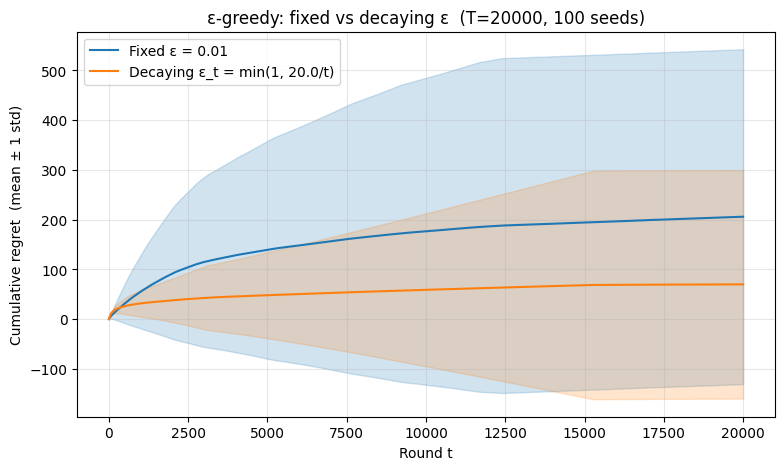

In [40]:
# === Task 1, Part C: decaying ε vs best fixed ε ===

# A decaying-ε variant: at round t (1-indexed), use ε_t = min(1, c/t).
# Early rounds explore aggressively; later rounds barely explore.


def epsilon_greedy_decaying(env, T, c):
    """ε-greedy with ε_t = min(1, c/(t+1)).  Same logic as epsilon_greedy
    otherwise — only the exploration probability changes per round."""
    K = env.K
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)
    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)
    for t in range(T):
        eps_t = min(1.0, c / (t + 1))  # +1 so we don't divide by zero at t=0
        if env.rng.random() < eps_t:
            a = int(env.rng.integers(K))
        else:
            with np.errstate(divide="ignore", invalid="ignore"):
                means = np.where(
                    counts > 0, sum_rewards / np.maximum(counts, 1), np.inf
                )
            best = means.max()
            candidates = np.flatnonzero(means == best)
            a = int(env.rng.choice(candidates))
        r = env.pull(a)
        sum_rewards[a] += r
        counts[a] += 1
        arm_sequence[t] = a
        regret_sequence[t] = env.instantaneous_regret(a)
    return arm_sequence, regret_sequence


T = 20000
n_seeds = 100
c = 20.0  # decay constant — try changing this!
best_fixed_eps = (
    0.01  # winner from Part B at T=20000 — used here as a strong fixed baseline
)

# Run both algorithms.
algo_fixed = partial(epsilon_greedy, epsilon=best_fixed_eps)
algo_decay = partial(epsilon_greedy_decaying, c=c)
regret_fixed, _ = run_experiment(algo_fixed, env_factory_5arm, T, n_seeds)
regret_decay, _ = run_experiment(algo_decay, env_factory_5arm, T, n_seeds)

# Plot: averaged cumulative regret over time, both algorithms.
fig, ax = plt.subplots(figsize=(9, 5))
plot_averaged_regret(regret_fixed, f"Fixed ε = {best_fixed_eps}", ax)
plot_averaged_regret(regret_decay, f"Decaying ε_t = min(1, {c}/t)", ax)
ax.set_title(f"ε-greedy: fixed vs decaying ε  (T={T}, {n_seeds} seeds)")
plt.show()

In [51]:
# indices where cumulative regret of fixed ε is less than cumulative regret of decaying ε
np.where(np.cumsum(regret_fixed, axis=1).mean(axis=0) < np.cumsum(regret_decay, axis=1).mean(axis=0))

(array([  5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,
         18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,
         31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,
         83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
         96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108,
        109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
        122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,
        135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
        148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160,
        161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173,
        174, 175, 176, 177, 178, 179, 180, 181, 182

**Observe and write up (TODO).** Looking at the plot above:

1. Compare the two curves over time. Which one wins early, which wins later, and roughly when does the crossover happen (if any)?

2. Why might a decaying schedule eventually outperform any fixed ε?

3. The decay constant $c$ had to be tuned (we picked $c = 20$ here). Try a few other values of $c$ in the cell above and see what happens. What does this tell you?

**Observations:**

1. Very early on, the fixed $\epsilon$ curve has less cumulative regret. But at T=344, cross-over happens and after that till end (T=20000), decaying $\epsilon$ has less cumulative regret than fixed.
2. As we saw earlier, best $\epsilon$ probability eventually decreases with number of rounds $T$. Thus a decaying schedule is bound to eventually outperform any fixed $\epsilon$ because it keeps reducing $\epsilon$ with increasing $T$.
3. Trying some lower and some higher values of decay constant shows that at values other than ideal $c = 20$, the crossover happens at a much later $T$, and the final gap between decaying and fixed epsilon is reduced. Meaning that $c = 20$ only is the correct decay constant as otherwise performance degrades of decaying $\epsilon$ curve.

---

## Task 2 — Explore-Then-Commit (3 marks)

ETC is the simplest committal algorithm. With a 2-arm bandit and exploration budget $m$: pull arm 0 a total of $m$ times, pull arm 1 a total of $m$ times, then commit to whichever arm has the higher empirical mean for all remaining rounds.

The interesting parameter is $m$. Too small and you may commit to the wrong arm and pay regret linearly in $T$. Too large and you waste exploration rounds you didn't need.

In this task you'll implement ETC and study it from three angles, all on 2-arm Bernoulli bandits parameterised by the gap $\Delta$: arm means are $(0.5 + \Delta/2,\, 0.5 - \Delta/2)$.

**Part A (1 mark):** Reproduce Figure 6.2 from Lattimore & Szepesvári — regret vs $m$ at one fixed $\Delta$.

**Part B (1 mark):** Reproduce Figure 7.1 (without UCB) — regret vs $\Delta$ for several fixed $m$, plus an "optimal $m$" envelope.

**Part C (1 mark):** Combine A and B into a single $(m, \Delta)$ heatmap and connect the views.

**How this task works.** You implement ETC once, in a code cell marked `# TODO`. The experiment and plotting code is provided. Your job is to (1) get the algorithm right and (2) write thoughtful observations.

In [ ]:
# === Task 2: ETC implementation ===


def etc(env, T, m):
    """Explore-Then-Commit on a 2-arm bandit.

    Phase 1 (rounds 0 .. 2m-1):
        Pull arm 0 for m rounds, then arm 1 for m rounds.
        (For 2-arm ETC the order does not affect regret in expectation;
         we go arm 0 first, then arm 1, for simplicity.)

    Phase 2 (rounds 2m .. T-1):
        Commit to whichever arm has the higher empirical mean.
        Break ties uniformly at random using env.rng.

    If 2m >= T, only phase 1 runs (truncated at T).

    Parameters
    ----------
    env : BernoulliBandit  with env.K == 2
    T : int                horizon
    m : int                exploration budget per arm

    Returns
    -------
    arm_sequence    : (T,) int     arm pulled at each round
    regret_sequence : (T,) float   instantaneous (expected) regret per round
    """
    assert env.K == 2, "This ETC implementation assumes 2 arms."
    K = env.K
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)

    for t in range(min(2 * m, T)):       # phase 1: explore each arm for m rounds each
        a = t // m   # first arm 0, then arm 1
        r = env.pull(a)
        sum_rewards[a] += r
        counts[a] += 1
        arm_sequence[t] = a
        regret_sequence[t] = env.instantaneous_regret(a)

    # Phase 2: commit to the better arm
    if 2 * m < T:
        with np.errstate(divide="ignore", invalid="ignore"):
            means = np.where(
                counts > 0, sum_rewards / np.maximum(counts, 1), np.inf
            )
        best = means.max()
        candidates = np.flatnonzero(means == best)
        a = int(env.rng.choice(candidates))         # best arm after exploration, with tie-breaking
        for t in range(2 * m, T):
            r = env.pull(a)
            arm_sequence[t] = a
            regret_sequence[t] = env.instantaneous_regret(a)

    return arm_sequence, regret_sequence

### Part A: regret vs $m$ at fixed $\Delta$ (Fig 6.2 style)

Fix $\Delta$ and $T$. Sweep the exploration budget $m$ and plot mean cumulative regret at horizon $T$ as a function of $m$.

  0%|          | 0/40 [00:00<?, ?it/s]

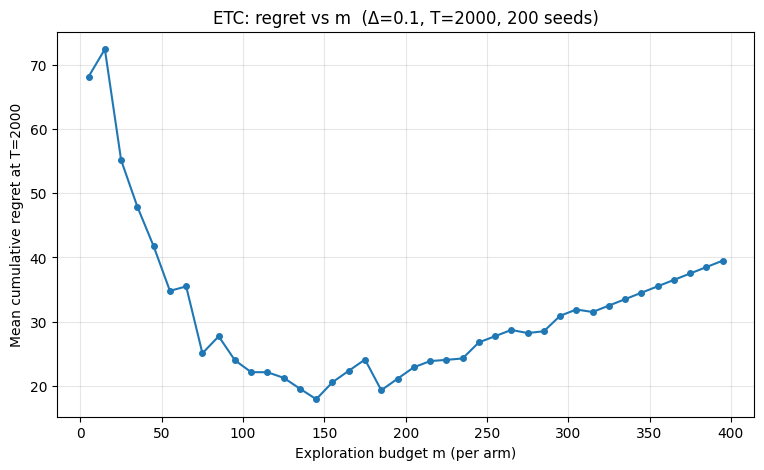

In [60]:
# === Task 2, Part A: regret vs m at fixed Δ ===

T = 2000
Delta_A = 0.1
n_seeds = 200   # 50  # bump this up (e.g. to 200) if the curve looks too jagged
m_values_A = np.arange(5, 401, 10)  # 5, 15, 25, ..., 395


def make_env_factory(Delta):
    """Builds a 2-arm Bernoulli env with means (0.5 + Δ/2, 0.5 - Δ/2)."""

    def env_factory(rng):
        return BernoulliBandit([0.5 + Delta / 2, 0.5 - Delta / 2], rng)

    return env_factory


env_factory = make_env_factory(Delta_A)

# Sweep m, collecting mean final regret at each.
final_regret_by_m = []
for m in tqdm(m_values_A):
    algo = partial(etc, m=int(m))
    regret_matrix, _ = run_experiment(algo, env_factory, T, n_seeds, progress_bar=False)
    final_regret = np.cumsum(regret_matrix, axis=1)[:, -1].mean()
    final_regret_by_m.append(final_regret)
final_regret_by_m = np.array(final_regret_by_m)

# Plot.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(m_values_A, final_regret_by_m, marker="o", markersize=4)
ax.set_xlabel("Exploration budget m (per arm)")
ax.set_ylabel(f"Mean cumulative regret at T={T}")
ax.set_title(f"ETC: regret vs m  (Δ={Delta_A}, T={T}, {n_seeds} seeds)")
plt.show()

**Observe and write up (TODO).** Looking at the plot above:

1. Describe the **shape** of the curve. You should see a V (or U) — explain in your own words what's happening on the **left** arm (small $m$) vs the **right** arm (large $m$).

2. Roughly where is the minimum? Is the minimum **sharp** or **broad**? What does that imply about how carefully $m$ needs to be tuned?

3. The two arms of the V come from **different failure modes**. Are they symmetric, or is one arm steeper than the other? Why?

*(Note: if your curve looks jagged, you can bump up `n_seeds` to smooth it out — at the cost of longer runtime.)*

**Observations:**

1. Curve is roughly *V-shaped*, where on the left (small m) Mean Cumuulative Regret first rapidly decreases to a minimum at an exploration budget $m$, then  at the right (large m) Mean Cumulative Regret gradually increases again from the minimum.
2. The minimum is in a **broad** range where it's almost flat (i.e. roughly between m = 100 to 200). This implies that while tuning $m$, some amount of error tolerance exists so that even if exact best m isn't chosen, still the performance would not worsen too much as long as it is within this range (m = 100 to 200).
3. The 2 arms of the V are *not symmetric* - left (small $m$) has a much sharper decrease in Mean Cumulative Regret than the right (large $m$) has increase. This is because when exploration budget $m$ is very small, regret is very high due to very early committing to one arm, and so we can greatly boost performance by increasing exploration. But when $m$ gets large (around half way point from max T = 400), now regret starts to worsen due to too much exploration which increases effect of noise / randomness.

### Part B: regret vs $\Delta$ for several fixed $m$ (Fig 7.1 style)

Now flip the axes: fix $T$, pick a few values of $m$, and sweep $\Delta$. Each curve shows how a fixed-$m$ strategy fares across different bandit instances. Add a fifth curve — the "optimal $m$" envelope — that picks the best $m$ for each $\Delta$.

Sweep Δ for each fixed m.


  0%|          | 0/20 [00:00<?, ?it/s]

Optimal-m envelope: at each Δ, find best m on the finer grid.


  0%|          | 0/20 [00:00<?, ?it/s]

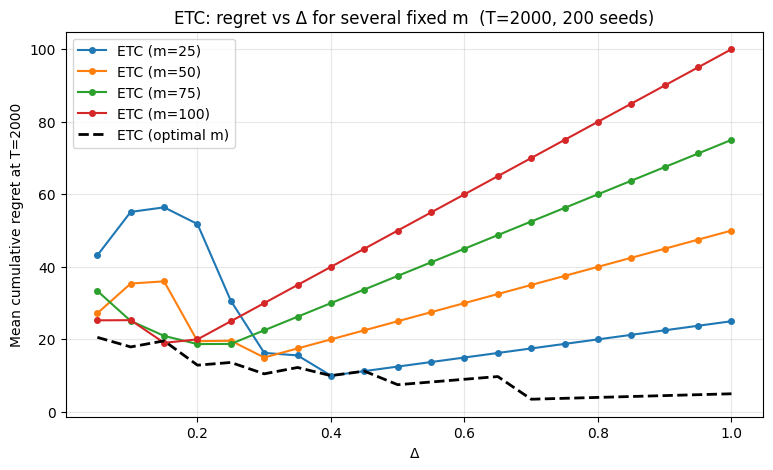

In [63]:
# === Task 2, Part B: regret vs Δ for several fixed m ===

T = 2000
n_seeds = 200 # 50  # bump this up if curves look jagged; runtime scales linearly
Delta_values_B = np.linspace(0.05, 1.0, 20)
m_values_fixed = [25, 50, 75, 100]
m_values_for_envelope = np.arange(5, 401, 10)  # finer grid for the envelope

print('Sweep Δ for each fixed m.')
regret_fixed_m = {m: [] for m in m_values_fixed}
for Delta in tqdm(Delta_values_B):
    env_factory = make_env_factory(Delta)
    for m in m_values_fixed:
        algo = partial(etc, m=m)
        rm, _ = run_experiment(algo, env_factory, T, n_seeds, progress_bar=False)
        regret_fixed_m[m].append(np.cumsum(rm, axis=1)[:, -1].mean())

print('Optimal-m envelope: at each Δ, find best m on the finer grid.')
optimal_envelope = []
for Delta in tqdm(Delta_values_B):
    env_factory = make_env_factory(Delta)
    best_so_far = np.inf
    for m in m_values_for_envelope:
        algo = partial(etc, m=int(m))
        rm, _ = run_experiment(algo, env_factory, T, n_seeds, progress_bar=False)
        r = np.cumsum(rm, axis=1)[:, -1].mean()
        if r < best_so_far:
            best_so_far = r
    optimal_envelope.append(best_so_far)

# Plot.
fig, ax = plt.subplots(figsize=(9, 5))
for m in m_values_fixed:
    ax.plot(
        Delta_values_B,
        regret_fixed_m[m],
        marker="o",
        markersize=4,
        label=f"ETC (m={m})",
    )
ax.plot(
    Delta_values_B,
    optimal_envelope,
    color="black",
    linewidth=2,
    linestyle="--",
    label="ETC (optimal m)",
)
ax.set_xlabel("Δ")
ax.set_ylabel(f"Mean cumulative regret at T={T}")
ax.set_title(f"ETC: regret vs Δ for several fixed m  (T={T}, {n_seeds} seeds)")
ax.legend()
plt.show()

**Observe and write up (TODO).** Looking at the plot above:

1. Pick one fixed-$m$ curve. Describe its shape as $\Delta$ varies from small to large. Why does it have that shape?

2. The peak of each fixed-$m$ curve shifts as $m$ changes. Which direction does the peak move as $m$ grows? Why?

3. The optimal-$m$ envelope sits below all the fixed-$m$ curves (by definition). What does the **gap** between the envelope and each fixed-$m$ curve tell you about ETC?

**Observations:**

1. Picking one curve $m = 25$, we see that it has **inverted S-shape** first reaches maximum Mean Cumulative Regret, then rapidly reaches point of minimum regret, and then increases again. This is because, at the left (low $\Delta$), initial arm means are very close together which means it is very difficult for the algorithm to distinguish the best arm, so regret is high. Then as we increase $\Delta$, regret rapidly reduces. Finally at the end only pure exploration cost remains which is why at the end regret increases slowly linearly.
2. As $m$ increases, both the peak and the lowest point on the curves shift to the left (lower $\Delta$). Probability of error drops exponentially with $\exp{-m \Delta^2}$. With a small $m$, the algorithm takes very few steps and gets fooled even with a large $\Delta$. But with a larger $m$, we collect a lot more data meaning it's more easy to clear the same $\Delta$, so it's only fooled by an extremely small $\Delta$.
3. The optimal-$m$ envelope is not the performance of a real $m$ curve, but instead a hypothetical curve of what it would look like if we somehow knew the perfect $m$ at every step. So the gap represents *price of misaligned exploration* at each step. Here we can see that the "optimal" $m$ at each step is different with different environment $\Delta$ (i.e. a different $m$ curve is closest), so we need a more adaptive strategy.

### Part C: $(m, \Delta)$ heatmap

Combine Parts A and B into one picture: sweep both $m$ and $\Delta$, plot mean regret as a 2D heatmap.

  0%|          | 0/15 [00:00<?, ?it/s]

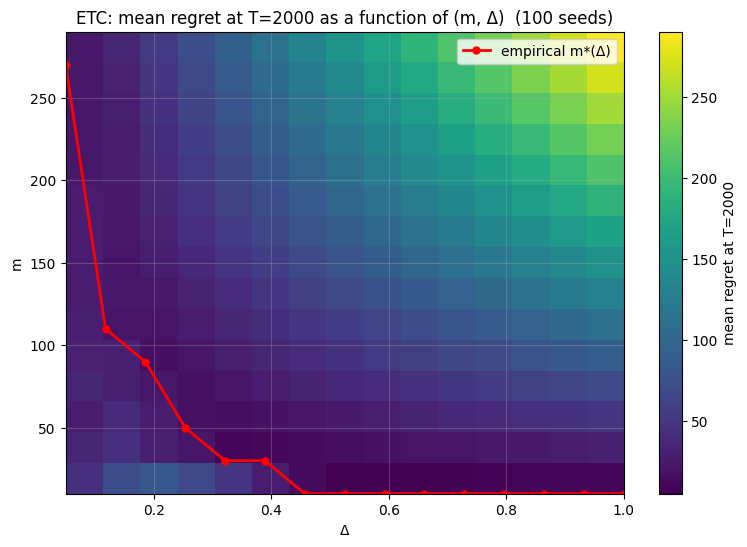

In [65]:
# === Task 2, Part C: (m, Δ) heatmap ===

T = 2000
n_seeds = 100
m_values_C = np.arange(10, 301, 20)  # 15 values
Delta_values_C = np.linspace(0.05, 1.0, 15)  # 15 values

# Build the regret grid: rows = m, cols = Δ.
regret_grid = np.zeros((len(m_values_C), len(Delta_values_C)))
for j in trange(len(Delta_values_C)):
    Delta = Delta_values_C[j]
    env_factory = make_env_factory(Delta)
    for i, m in enumerate(m_values_C):
        algo = partial(etc, m=int(m))
        rm, _ = run_experiment(algo, env_factory, T, n_seeds, progress_bar=False)
        regret_grid[i, j] = np.cumsum(rm, axis=1)[:, -1].mean()

# Plot.
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    regret_grid,
    origin="lower",
    aspect="auto",
    extent=[Delta_values_C[0], Delta_values_C[-1], m_values_C[0], m_values_C[-1]],
    cmap="viridis",
)
# Mark m*(Δ) — the empirical argmin along each column.
m_star = m_values_C[np.argmin(regret_grid, axis=0)]
ax.plot(
    Delta_values_C,
    m_star,
    color="red",
    linewidth=2,
    marker="o",
    markersize=5,
    label="empirical m*(Δ)",
)
ax.set_xlabel("Δ")
ax.set_ylabel("m")
ax.set_title(f"ETC: mean regret at T={T} as a function of (m, Δ)  ({n_seeds} seeds)")
plt.colorbar(im, ax=ax, label=f"mean regret at T={T}")
ax.legend(loc="upper right")
plt.show()

**Observe and write up (TODO).** Looking at the heatmap above:

1. The red curve traces empirical $m^*(\Delta)$ — the best $m$ at each $\Delta$. Describe its trajectory. How does $m^*$ depend on $\Delta$, and why does that make intuitive sense?

2. **Connect to Part A.** A vertical slice of this heatmap at fixed $\Delta$ is the plot you made in Part A. Pick the column closest to $\Delta = 0.1$ and trace it from bottom to top — does it match the V-shape you saw?

3. **Connect to Part B.** A horizontal slice at fixed $m$ is one of the curves from Part B. Pick a row near $m = 50$ and trace it left to right — does the peak you saw in Part B show up here?

**Observations:**

1. Best $m^*$ (how much we should explore before committing) reduces quadratically with $\Delta$ until it reaches minimum regret - then it flat-lines. This makes sense, since the larger the difference there is from start between arm means, the easier it is to choose best arm and hence requires less exploration budget $m$ for optimality.s
2. Yes it matches -- from the color of heatmap in column of $\Delta = 0.1$ (bottom to top), we can see that the Mean Cumulative Regret first reduces to minimum and then gradually increases again.
3. Yes it matches -- from the color of heatmap we can see that the Mean Cumulative Regret in row $m = 40$ (left to right) peaks, then reduces and then increases again, which is the same pattern we saw earlier.

---

## Task 3 — Successive Elimination (4 marks)

You met Successive Elimination (SE) in class as a *best-arm identification* algorithm: maintain a set of "active" arms, pull each in round-robin, and eliminate arms whose upper confidence bound falls below another arm's lower confidence bound. The algorithm terminates when only one arm is left.

In this task you'll implement SE, but study it through **two lenses**:

- As a regret-minimisation algorithm (Parts A, C): what does its cumulative regret look like over time?
- As a best-arm identification algorithm (Parts B, D): how many samples does it take to find the best arm?

You'll see that these two views are connected — the BAI dynamics are *visible inside the regret curve*.

**Algorithm details for this task.** We use Hoeffding-style confidence widths:

$$
\widehat{\mu}_i(t) \pm U_i(t), \qquad U_i(t) = \sqrt{\frac{2 \log(1/\delta)}{N_i(t)}}
$$

where $N_i(t)$ is the number of times arm $i$ has been pulled so far, and $\delta$ is the confidence parameter (we'll use $\delta = 1/T^2$). Arm $i$ is eliminated as soon as some other arm $j$ has $\widehat{\mu}_j - U_j > \widehat{\mu}_i + U_i$.

**Two versions of SE.** Pure SE terminates as soon as one arm is left — but then how do you score it on cumulative regret over a fixed horizon? The standard trick: once SE terminates, **commit to the surviving arm for the rest of the horizon**. We call this `se_with_commit`. That's the version you'll implement; we also return the **stop time** (round at which SE terminated, or $T$ if it never did) so we can study BAI behaviour.

**Parts:**

- **Part A (1 mark):** Implement SE and plot per-seed cumulative regret trajectories over time.
- **Part B (1 mark):** Sample complexity: how the stop time scales with the gap $\Delta$.
- **Part C (1 mark):** Pull-count distribution across arms.
- **Part D (1 mark):** Stop-time distribution across seeds.

**How this task works.** You implement SE once, in a code cell marked `# TODO`. Everything else is provided. Your job is to (1) get the algorithm right, (2) run the cells, and (3) write thoughtful observations.

In [ ]:
# === Task 3: Successive Elimination implementation ===


def se_with_commit(env, T, delta):
    """Successive Elimination with commit-to-survivor.

    Pulls active arms in round-robin. After each round, eliminates any arm whose
    upper confidence bound falls below some other arm's lower confidence bound.
    Once only one arm remains (or T is reached), commits to the surviving arm
    for all remaining rounds.

    Confidence width: U_i(t) = sqrt(2 * log(1/delta) / N_i(t)).

    Parameters
    ----------
    env : BernoulliBandit
    T : int                horizon
    delta : float          confidence parameter

    Returns
    -------
    arm_sequence    : (T,) int     arm pulled at each round
    regret_sequence : (T,) float   instantaneous (expected) regret per round
    stop_time : int                round at which SE terminated (or T if it never did)
    """
    K = env.K
    arm_sequence = np.zeros(T, dtype=int)
    regret_sequence = np.zeros(T)

    sum_rewards = np.zeros(K)
    counts = np.zeros(K, dtype=int)
    active = np.ones(K, dtype=bool)  # boolean mask of currently-active arms
    log_term = 2.0 * np.log(1.0 / delta)

    stop_time = T  # default: never terminates within T

    t = 0
    while t < T:
        # ---- Active-set round-robin phase ----
        if active.sum() > 1:
            # pull each active arm once
            for a in range(K):
                if active[a]:
                    r = env.pull(a)
                    sum_rewards[a] += r
                    counts[a] += 1
                    arm_sequence[t] = a
                    regret_sequence[t] = env.instantaneous_regret(a)
                    t += 1
                    if t >= T:
                        return arm_sequence, regret_sequence, stop_time

            # calculate empirical means and confidence widths        
            means = sum_rewards / np.maximum(counts, 1)  # avoid divide-by-zero
            U = np.sqrt(log_term / np.maximum(counts, 1))

            # eliminate arms whose Upper Confidence Bound is below some other arm's Lower Confidence Bound
            for i in range(K):
                if active[i]:
                    for j in range(K):
                        if active[j] and means[j] - U[j] > means[i] + U[i]:
                            active[i] = False       
                            break

            if active.sum() == 1:      # only one arm left, record stop time; from now on we will commit to this arm only
                stop_time = t
        else:
            # ---- Commit phase: one active arm left, pull it for the rest. ----
            survivor = int(np.flatnonzero(active)[0])
            while t < T:
                env.pull(survivor)
                arm_sequence[t] = survivor
                regret_sequence[t] = env.instantaneous_regret(survivor)
                t += 1

    return arm_sequence, regret_sequence, stop_time

### Part A: SE trajectories over time

A standard 4-arm Bernoulli bandit with means $[0.2, 0.4, 0.6, 0.8]$, horizon $T = 10000$, 50 seeds. The cell below plots **every seed's cumulative regret trajectory** (faded), with the mean across seeds overlaid in bold red — the same style you saw on slide 16 of Lecture 4.

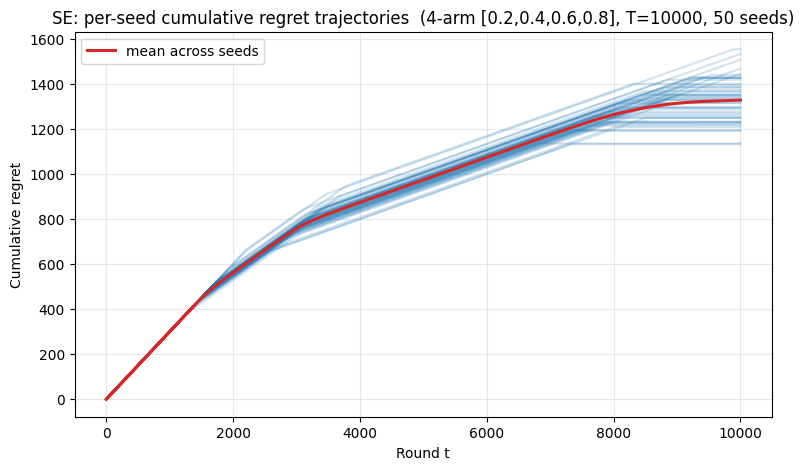

In [67]:
# === Task 3, Part A: SE trajectories ===

T = 10000
n_seeds = 50


def env_factory_4arm(rng):
    """4-arm Bernoulli env used in Parts A, C, D."""
    return BernoulliBandit([0.2, 0.4, 0.6, 0.8], rng)


# Run SE for each seed.  We bypass run_experiment because se_with_commit
# returns a 3-tuple (arms, regrets, stop_time) — we need that stop_time
# for Part D, so we loop manually and store it alongside the regret matrix.
delta = 1.0 / T**2

regret_matrix = np.zeros((n_seeds, T))
arm_matrix = np.zeros((n_seeds, T), dtype=int)
stop_times_4arm = np.zeros(n_seeds, dtype=int)

for s in range(n_seeds):
    rng = np.random.default_rng(BASE_SEED + s)
    env = env_factory_4arm(rng)
    arms, regrets, stop_t = se_with_commit(env, T, delta)
    regret_matrix[s] = regrets
    arm_matrix[s] = arms
    stop_times_4arm[s] = stop_t

cum_matrix = np.cumsum(regret_matrix, axis=1)

# Plot: every seed faded, mean in bold.
fig, ax = plt.subplots(figsize=(9, 5))
for s in range(n_seeds):
    ax.plot(cum_matrix[s], color="C0", alpha=0.2)
ax.plot(cum_matrix.mean(axis=0), color="C3", linewidth=2.2, label="mean across seeds")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret")
ax.set_title(
    f"SE: per-seed cumulative regret trajectories  (4-arm [0.2,0.4,0.6,0.8], T={T}, {n_seeds} seeds)"
)
ax.legend()
plt.show()

**Observe and write up (TODO).** Looking at the plot above:

1. Most trajectories **plateau** at some point — the cumulative regret stops growing. What does each plateau correspond to **as a BAI event**? (Hint: think about what SE does internally.)

2. The mean (red) curve has visible **slope changes** before flattening. What does each slope change correspond to? (Hint: in the 4-arm setup, how many arms are there to eliminate before SE terminates?)

3. Are there any seeds that **don't plateau** within $T = 10000$? What's happening in those runs? Is there anything you can say about how those would behave if you ran them longer?

**Observations**:

1. In terms of **Best Arm Identification (BAI)**, each curve's plateau represents the point when cumulative regret stops growing because we have successfully found the best arm, and now only that arm is being pulled every time.
2. In 4-arm bandit setup, 3 arms have to be eliminated before only 1 arm remains, and after that this arm only is always used. **Slope changes 3 times** -- i.e. 4 pieces of curves have 4 different slopes, with final slope at end being flat (plateau).
3. For some seeds, curves don't plateau within T = 10000 because in these runs they are taking longer to eliminate successive arms. We can see that most arms have been eliminated in these curves, and if we ran them longer they too would plateau.

### Part B: sample complexity vs $\Delta$

How does the **stop time** of SE scale with the gap $\Delta$? Theory predicts $\sim 1/\Delta^2$ — so on a log-log plot of stop time vs $1/\Delta$, we should see a line of slope $\approx 2$.

We run SE on **2-arm** Bernoulli bandits with means $(0.5 + \Delta/2,\, 0.5 - \Delta/2)$ for several values of $\Delta$. We use a large $T$ so SE has time to terminate on most seeds even at small $\Delta$.

Running SE with Δ = 0.1...


  0%|          | 0/50 [00:00<?, ?it/s]

Running SE with Δ = 0.15...


  0%|          | 0/50 [00:00<?, ?it/s]

Running SE with Δ = 0.2...


...

  0%|          | 0/50 [00:00<?, ?it/s]

Running SE with Δ = 0.7...


  0%|          | 0/50 [00:00<?, ?it/s]

Running SE with Δ = 1.0...


  0%|          | 0/50 [00:00<?, ?it/s]

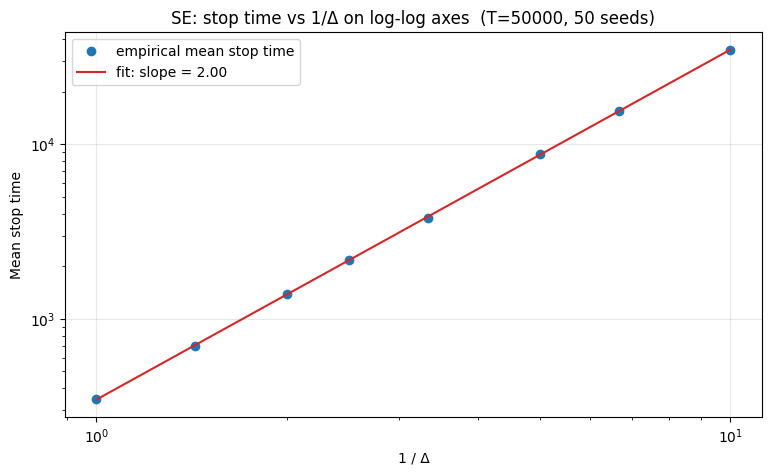

Fitted slope: 2.005
(Theory predicts ≈ 2.)


In [70]:
# === Task 3, Part B: stop time vs Δ (log-log) ===

T_B = 50000
n_seeds = 50
Delta_values_B = np.array([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0])

mean_stop_times = []
for Delta in Delta_values_B:
    print(f'Running SE with Δ = {Delta}...')
    env_factory = make_env_factory(Delta)
    stops = []
    delta_param = 1.0 / T_B**2
    for s in trange(n_seeds):
        rng = np.random.default_rng(BASE_SEED + s)
        env = env_factory(rng)
        _, _, stop_t = se_with_commit(env, T_B, delta_param)
        stops.append(stop_t)
    mean_stop_times.append(np.mean(stops))
mean_stop_times = np.array(mean_stop_times)

# Fit a line on log-log axes:  log(stop_time) = a + b * log(1/Δ).
log_inv_Delta = np.log(1.0 / Delta_values_B)
log_stop = np.log(mean_stop_times)
slope, intercept = np.polyfit(log_inv_Delta, log_stop, 1)

# Plot.
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(
    1.0 / Delta_values_B,
    mean_stop_times,
    marker="o",
    linestyle="none",
    label="empirical mean stop time",
)
# Fitted line.
xs = np.array([1.0 / Delta_values_B.max(), 1.0 / Delta_values_B.min()])
ax.loglog(
    xs, np.exp(intercept) * xs**slope, color="C3", label=f"fit: slope = {slope:.2f}"
)
ax.set_xlabel("1 / Δ")
ax.set_ylabel("Mean stop time")
ax.set_title(f"SE: stop time vs 1/Δ on log-log axes  (T={T_B}, {n_seeds} seeds)")
ax.legend()
plt.show()

print(f"Fitted slope: {slope:.3f}")
print(f"(Theory predicts ≈ 2.)")

**Observe and write up (TODO).** Looking at the plot above:

1. What slope do you observe? Does it agree with the theoretical prediction of 2? What does the slope value imply about how stop time scales with $\Delta$?

2. Where does the slope-2 prediction come from? (Hint: the confidence width is $U_i \propto 1/\sqrt{N_i}$. SE terminates roughly when the width is smaller than half the gap $\Delta$. Solve for $N_i$.)

3. Are there any visible deviations from a clean line? If so, at which end of the $\Delta$ range, and why might that be?

**Observations**:

1. Predicted slope is 2.005 which is very close to theoritical prediction of 2. So $MeanStopTime = 2 / \Delta + InitialConstant$ -- slope is how fast stop time inversely scales with $\Delta$.
2. Let $c$ be a constant, then for SE to terminate, $U_i = c / \sqrt{N_i} < \Delta / 2 => N_i = (2 c / \Delta)^2$. But we know that Mean Stop Time $T \propto N_i \propto 1 / \Delta^2$. Taking logarithms, $\ln{T} = -2 \ln{Delta} + SomeConstant$. Therefore absolute magnitude of theoritical slope is 2.
3. There are slight deviations from clean line at both ends of the $\Delta$ range. On the left ($\Delta$ near 0), the experiment requires many more rounds to find best arm, but we force it to stop at $T = 10000$ so slope here deviates from 2. On the right ($\Delta= = 1$), even one arm always gives reward 1 and the other always 0, algorithm still cannot immediately identify the best arm and instead must wait a minimum number of times which puts a lower limit on the stop time.

### Part C: pull counts per arm

The cell below uses the 4-arm Part A run to plot the mean pull count for each arm across seeds, across the **entire** horizon $T$. This includes the post-termination commit phase: once SE has identified the survivor, those rounds all add to the survivor's pull count. So this plot answers "how was the total budget of $T$ rounds spent across arms?" — which is the regret-side view. (A pure-SE pull-count plot up to `stop_time` would tell a related but slightly different story.)

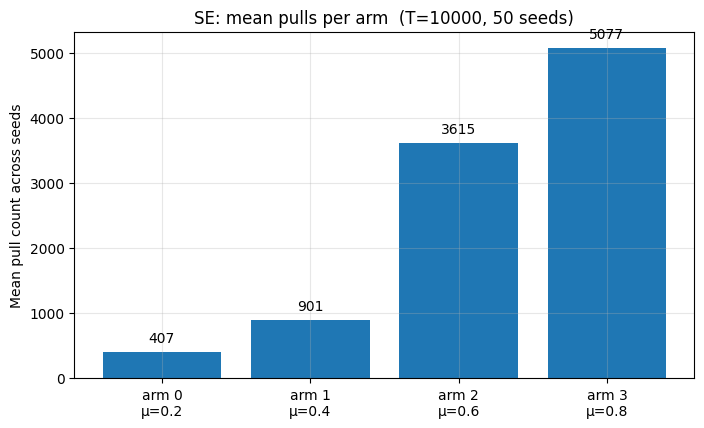

In [71]:
# === Task 3, Part C: mean pull counts per arm ===

K = 4
arm_means_4arm = [0.2, 0.4, 0.6, 0.8]
mean_pulls = np.zeros(K)
for k in range(K):
    mean_pulls[k] = np.mean((arm_matrix == k).sum(axis=1))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(np.arange(K), mean_pulls, color="C0")
for k, val in enumerate(mean_pulls):
    ax.text(
        k,
        val + 0.02 * mean_pulls.max(),
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_xticks(np.arange(K))
ax.set_xticklabels([f"arm {k}\nμ={m}" for k, m in enumerate(arm_means_4arm)])
ax.set_ylabel("Mean pull count across seeds")
ax.set_title(f"SE: mean pulls per arm  (T={T}, {n_seeds} seeds)")
plt.show()

**Observe and write up (TODO).** Looking at the bar chart above:

1. The four arms are pulled very different numbers of times. Describe the pattern in 1-2 sentences.

2. Why does this pattern make sense, given how SE works? Connect it to the gap $\Delta_k = \mu^* - \mu_k$ for each suboptimal arm.

**Observations**:

1. The no. of times each arm is pulled decreases by their mean $\mu$.
2. This makes sense because arm with lowest mean naturally gets eliminated first (since its calculated Upper Confidence Bound is very likely to come less than Lower Confidence Bound of another arm, which is the criteria for elimination). So arms with least mean are pulled less, and arm with most means is pulled most because it remains sole surviving arm at the end. This is because number of arm pulls required to eliminate a bad arm shrinks quadratically with $\Delta$ : $N_i \propto 1 / \Delta^2$.

### Part D: stop-time distribution across seeds

Part A's mean curve hid run-to-run variation. The histogram below shows the **distribution of stop times** across the 50 seeds from Part A (4-arm bandit, $T=10000$). Bin at $T$ (rightmost) collects seeds that did not terminate within the horizon.

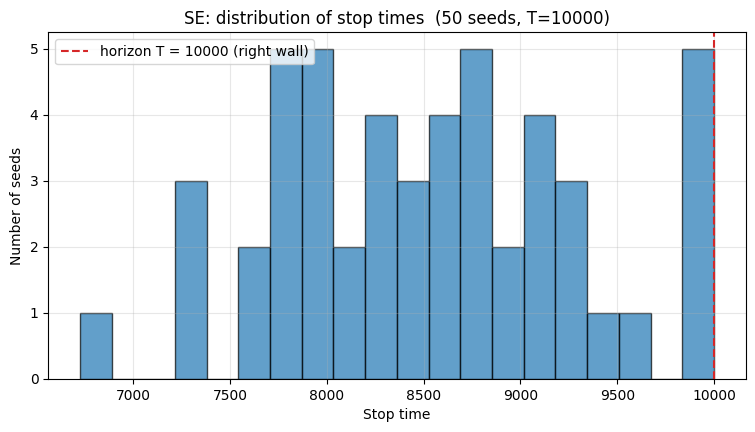

Seeds that terminated within T: 47/50
Mean stop time (terminated seeds only): 8445
Median stop time: 8530


In [72]:
# === Task 3, Part D: histogram of stop times ===

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(stop_times_4arm, bins=20, edgecolor="black", alpha=0.7)
ax.axvline(
    T, color="C3", linestyle="--", linewidth=1.5, label=f"horizon T = {T} (right wall)"
)
ax.set_xlabel("Stop time")
ax.set_ylabel("Number of seeds")
ax.set_title(f"SE: distribution of stop times  ({n_seeds} seeds, T={T})")
ax.legend()
plt.show()

n_terminated = int((stop_times_4arm < T).sum())
print(f"Seeds that terminated within T: {n_terminated}/{n_seeds}")
print(
    f"Mean stop time (terminated seeds only): {stop_times_4arm[stop_times_4arm < T].mean():.0f}"
)
print(f"Median stop time: {np.median(stop_times_4arm):.0f}")

**Observe and write up (TODO).** Looking at the histogram above:

1. Describe the **spread** of stop times across seeds. Is it tight or wide? What does the spread tell you about SE's behaviour?

2. How many seeds (if any) hit the right wall (didn't terminate within $T$)? What does this say about the horizon you'd need to "reliably" identify the best arm here?

**Observations**:

1. No. of terminating seeds at different stop times are *tightly* spread between 1-5. Other than some extreme outliers especially at the end, we can regard number of seeds terminating at each stop time very roughly as being normally distributed around the mean stop time (8445).
2. 5 seeds hit the right wall (didn't terminate within T). This implies that the "true horizon" time is farther off for where these runs would have terminated - they require about 2000 - 4000 rounds more for perfect true horizon to be found to "reliably" identify best arm.